# Notebook 06 — Регресійна модель (ML: Supervised)

Побудова регресійної моделі для передбачення індексу доступності.

## Ціль
Зрозуміти, **які чинники** найбільше впливають на транспортну доступність.

## Ознаки (features)
- `distance_to_center` — відстань до центру Києва (Майдан), км
- `distance_to_metro` — відстань до найближчої станції метро, км
- `population_density` — щільність населення в районі, чол/км²
- `facility_type_enc` — тип об'єкта (0=лікарня, 1=школа)

## Модель
**Gradient Boosting Regressor** (sklearn) — потужна ансамблева модель на дерегресіях рішень.

In [8]:
from config_loader import cfg, RANDOM_STATE
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print('Бібліотеки завантажено')

Бібліотеки завантажено


In [9]:
gpkg_data_path = '../data/osm/osm_data.gpkg'

df         = pd.read_csv('../data/processed/clustered_facilities.csv', encoding='utf-8')
population = pd.read_csv('../data/census/population.csv', encoding='utf-8')

# OSM дані
osm_gmetro = gpd.read_file(gpkg_data_path, layer='metro')

osm: dict[str, gpd.GeoDataFrame] = {
    'gmetro': osm_gmetro,
}

metro_gdf = osm['gmetro']

print(f'Об\'єктів: {len(df)}')
print(f'Станцій метро: {len(metro_gdf)}')
df[['facility_id','facility_type','lon','lat','accessibility_score']].head(3)

Об'єктів: 1231
Станцій метро: 52


,facility_id,facility_type,lon,lat,accessibility_score
0,H0,hospital,30.477746,50.467559,0.527324
1,H1,hospital,30.639359,50.410014,0.489758
2,H2,hospital,30.619042,50.398759,0.362605


## 1. Побудова ознак

### 1.1 Відстань до центру Києва (Майдан Незалежності)

In [10]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    """Відстань між двома точками на сфері (формула Гаверсинуса), км."""
    R = 6371  # радіус Землі, км
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1) * cos(phi2) * sin(dlambda/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# Координати Майдану Незалежності
MAIDAN_LAT, MAIDAN_LON = 50.4501, 30.5234

df['distance_to_center'] = df.apply(
    lambda row: haversine_km(row['lat'], row['lon'], MAIDAN_LAT, MAIDAN_LON),
    axis=1
)

print(f'Відстань до центру (середня): {df["distance_to_center"].mean():.2f} км')
print(f'Мінімум: {df["distance_to_center"].min():.2f} км')
print(f'Максимум: {df["distance_to_center"].max():.2f} км')

Відстань до центру (середня): 6.81 км
Мінімум: 0.41 км
Максимум: 23.25 км


### 1.2 Відстань до найближчої станції метро

In [11]:
# Координати станцій метро
metro_coords = [(row.geometry.y, row.geometry.x) for _, row in metro_gdf.iterrows()]

def min_distance_to_metro(lat, lon, metro_list):
    """Знаходить відстань до найближчої станції метро."""
    if not metro_list:
        return np.nan
    distances = [haversine_km(lat, lon, m_lat, m_lon) for m_lat, m_lon in metro_list]
    return min(distances)

df['distance_to_metro'] = df.apply(
    lambda row: min_distance_to_metro(row['lat'], row['lon'], metro_coords),
    axis=1
)

print(f'Відстань до метро (середня): {df["distance_to_metro"].mean():.2f} км')
print(f'Мінімум: {df["distance_to_metro"].min():.2f} км')
print(f'Максимум: {df["distance_to_metro"].max():.2f} км')

Відстань до метро (середня): 1.77 км
Мінімум: 0.06 км
Максимум: 15.90 км


### 1.3 Щільність населення (по районах)

Для простоти призначаємо район за найближчою популяційною одиницею.
Використовуємо центроїди районів Києва (приблизні координати).

In [12]:
# Приблизні центроїди районів Києва (lat, lon)
DISTRICT_CENTROIDS = {
    'Голосіївський':   (50.3833, 30.5167),
    'Дарницький':      (50.4167, 30.6167),
    'Деснянський':     (50.5167, 30.5833),
    'Дніпровський':    (50.4500, 30.6167),
    'Оболонський':     (50.5167, 30.5000),
    'Печерський':      (50.4333, 30.5500),
    'Подільський':     (50.4667, 30.5000),
    'Святошинський':   (50.4500, 30.3833),
    "Солом'янський":   (50.4333, 30.4667),
    'Шевченківський':  (50.4500, 30.5000),
}

# Словник: назва → щільність
district_density = population.set_index('district')['density_per_km2'].to_dict()

def assign_district_density(lat, lon):
    """Призначає щільність населення за найближчим районом."""
    min_dist = float('inf')
    nearest_density = 0
    for district, (dlat, dlon) in DISTRICT_CENTROIDS.items():
        d = haversine_km(lat, lon, dlat, dlon)
        if d < min_dist:
            min_dist = d
            nearest_density = district_density.get(district, 0)
    return nearest_density

df['population_density'] = df.apply(
    lambda row: assign_district_density(row['lat'], row['lon']),
    axis=1
)

print(f'Щільність населення (середня): {df["population_density"].mean():.0f} чол/км²')

Щільність населення (середня): 4723 чол/км²


### 1.4 Кодування типу об'єкта

In [13]:
df['facility_type_enc'] = (df['facility_type'] == 'school').astype(int)

FEATURE_COLS   = ['distance_to_center', 'distance_to_metro', 'population_density', 'facility_type_enc']
TARGET_PEAK    = 'score_peak'
TARGET_OFFPEAK = 'score_offpeak'

# Перевіряємо наявність нових колонок (якщо NB04/NB05 вже перезапущені)
if TARGET_PEAK not in df.columns:
    df[TARGET_PEAK]    = df['accessibility_score']
if TARGET_OFFPEAK not in df.columns:
    df[TARGET_OFFPEAK] = df['accessibility_score']

df_model = df[FEATURE_COLS + [TARGET_PEAK, TARGET_OFFPEAK]].dropna()
print(f'Набір для моделювання: {len(df_model)} рядків')
df_model[FEATURE_COLS].describe().round(3)

Набір для моделювання: 1231 рядків


,distance_to_center,distance_to_metro,population_density,facility_type_enc
count,1231.000,1231.000,1231.000,1231.000
mean,6.810,1.775,4723.434,0.461
std,3.458,1.966,2542.083,0.499
min,0.413,0.061,1587.000,0.000
25%,4.235,0.565,2421.000,0.000
50%,6.854,1.027,3097.000,0.000
75%,9.063,2.446,5826.000,1.000
max,23.253,15.898,9581.000,1.000


## 2. Кореляційний аналіз

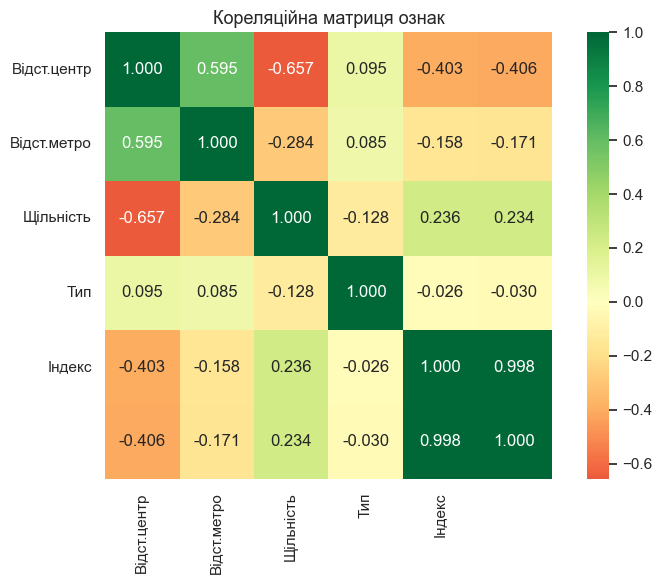

Кореляція з індексом доступності:


NameError: name 'TARGET_COL' is not defined

In [14]:
corr = df_model.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, square=True, ax=ax,
            xticklabels=['Відст.центр', 'Відст.метро', 'Щільність', 'Тип', 'Індекс'],
            yticklabels=['Відст.центр', 'Відст.метро', 'Щільність', 'Тип', 'Індекс'])
ax.set_title('Кореляційна матриця ознак', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Кореляція з індексом доступності:')
print(corr[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False).round(3))

## 3. Gradient Boosting Regressor

In [ ]:
X       = df_model[FEATURE_COLS].values
y_peak    = df_model[TARGET_PEAK].values
y_offpeak = df_model[TARGET_OFFPEAK].values

def train_gbr(X, y):
    """Навчання GradientBoostingRegressor з метриками на тестовій вибірці."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=cfg['regression']['test_size'], random_state=RANDOM_STATE
    )
    model = GradientBoostingRegressor(
        n_estimators=cfg['regression']['n_estimators'],
        learning_rate=0.05, max_depth=4, min_samples_split=5,
        subsample=0.8, random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return model, y_test, y_pred, rmse, mae, r2

model_peak,    y_test_peak,    y_pred_peak,    rmse_peak,    mae_peak,    r2_peak    = train_gbr(X, y_peak)
model_offpeak, y_test_offpeak, y_pred_offpeak, rmse_offpeak, mae_offpeak, r2_offpeak = train_gbr(X, y_offpeak)

print('=== ПОРІВНЯННЯ МЕТРИК МОДЕЛЕЙ ===')
metrics_df = pd.DataFrame({
    'Метрика': ['RMSE ↓', 'MAE ↓', 'R² ↑'],
    'Пік (score_peak)':       [round(rmse_peak,    4), round(mae_peak,    4), round(r2_peak,    4)],
    'Міжпік (score_offpeak)': [round(rmse_offpeak, 4), round(mae_offpeak, 4), round(r2_offpeak, 4)],
})
print(metrics_df.to_string(index=False))
print()
print(f'Пік:    R²={r2_peak:.4f}, пояснює {r2_peak*100:.1f}% дисперсії')
print(f'Міжпік: R²={r2_offpeak:.4f}, пояснює {r2_offpeak*100:.1f}% дисперсії')

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_peak    = cross_val_score(model_peak,    X, y_peak,    cv=cv, scoring='r2')
cv_offpeak = cross_val_score(model_offpeak, X, y_offpeak, cv=cv, scoring='r2')

print('5-fold крос-валідація (R²):')
print(f'{"Fold":>6} {"Пік":>10} {"Міжпік":>10}')
for i, (sp, so) in enumerate(zip(cv_peak, cv_offpeak)):
    print(f'{"Fold "+str(i+1):>6} {sp:>10.4f} {so:>10.4f}')
print(f'{"Сер.":>6} {cv_peak.mean():>10.4f} {cv_offpeak.mean():>10.4f}')
print(f'{"Std":>6} {cv_peak.std():>10.4f} {cv_offpeak.std():>10.4f}')

## 4. Важливість ознак (Feature Importance)

Показує, яка частка варіативності цільової змінної пояснюється кожною ознакою.

In [ ]:
FEATURE_NAMES_UA = [
    'Відстань до\nцентру міста',
    'Відстань до\nстанції метро',
    'Щільність\nнаселення',
    'Тип об\'єкта\n(лікарня/школа)',
]

imp_peak    = model_peak.feature_importances_
imp_offpeak = model_offpeak.feature_importances_

sort_idx = np.argsort((imp_peak + imp_offpeak) / 2)[::-1]
x = np.arange(len(FEATURE_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, imp_peak[sort_idx],    width,
               label='Пік (07-09, 17-19)', color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, imp_offpeak[sort_idx], width,
               label='Міжпік (10-17)',     color='#FF9800', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([FEATURE_NAMES_UA[i] for i in sort_idx], fontsize=10)
ax.set_title('Важливість ознак: пік vs міжпік (Gradient Boosting)', fontsize=13)
ax.set_ylabel('Важливість (частка поясненої дисперсії)')
ax.legend(fontsize=11)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#1565C0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#E65100')

ax.set_ylim(0, max(imp_peak.max(), imp_offpeak.max()) * 1.25)
plt.tight_layout()
plt.savefig('../outputs/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig('../outputs/11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ранжування ознак:')
for i in sort_idx:
    print(f'  {FEATURE_NAMES_UA[i].replace(chr(10)," "):35s}: пік={imp_peak[i]:.3f}, міжпік={imp_offpeak[i]:.3f}')

## 5. Передбачені vs фактичні значення

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (y_test, y_pred, r2, title_sfx) in enumerate([
    (y_test_peak,    y_pred_peak,    r2_peak,    f'Пік (R²={r2_peak:.3f})'),
    (y_test_offpeak, y_pred_offpeak, r2_offpeak, f'Міжпік (R²={r2_offpeak:.3f})'),
]):
    # Scatter: predicted vs actual
    axes[row, 0].scatter(y_test, y_pred, alpha=0.6, color='#2196F3',
                          edgecolors='white', s=30)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[row, 0].plot(lims, lims, 'r--', linewidth=1.5, label='Ідеальна модель')
    axes[row, 0].set_xlabel('Фактичний індекс')
    axes[row, 0].set_ylabel('Передбачений індекс')
    axes[row, 0].set_title(f'Передбачений vs фактичний — {title_sfx}', fontsize=11)
    axes[row, 0].legend()

    # Залишки
    residuals = y_test - y_pred
    axes[row, 1].scatter(y_pred, residuals, alpha=0.6, color='#FF9800',
                          edgecolors='white', s=30)
    axes[row, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row, 1].set_xlabel('Передбачений індекс')
    axes[row, 1].set_ylabel('Залишок (факт − прогноз)')
    axes[row, 1].set_title(f'Графік залишків — {title_sfx}', fontsize=11)

plt.suptitle('Оцінка якості регресійних моделей: пік vs міжпік', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/12_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_out = df[FEATURE_COLS + [TARGET_PEAK, TARGET_OFFPEAK, 'facility_id', 'facility_type', 'name']].dropna().copy()
df_out['predicted_score_peak']    = model_peak.predict(df_out[FEATURE_COLS].values)
df_out['predicted_score_offpeak'] = model_offpeak.predict(df_out[FEATURE_COLS].values)
df_out['residual_peak']    = df_out[TARGET_PEAK]    - df_out['predicted_score_peak']
df_out['residual_offpeak'] = df_out[TARGET_OFFPEAK] - df_out['predicted_score_offpeak']

# Аліаси для сумісності
df_out['accessibility_score'] = df_out[TARGET_PEAK]
df_out['predicted_score']     = df_out['predicted_score_peak']
df_out['residual']            = df_out['residual_peak']

df_out.to_csv('../data/processed/regression_results.csv', index=False, encoding='utf-8')

print('Файл збережено: data/processed/regression_results.csv')
print()
print('Notebook 06 виконано. Переходьте до 07_visualization.ipynb')